# Two-Island Coalescent Model

Formålet med denne notebook er at opstille og analyser en two-island coalescent model i Phasic for to bavian populationer. Jeg estimerer migrationrater og effektive populationsstørrelser ved hjælp af Method of Moments på SFS-data fra Notebook 03.
Artiklen (Sørensen et al. 2023) dokumenterer genflow mellem eastern yellow baboons og southern olive baboons og særligt den stærke forbindelse mellem western yellow og Kinda baboons. 

I denne notebook vil jeg komme ind på følgende:

1. [Imports og data](#1-imports-og-data)
2. [Two-island modellen med StateIndexer](#2-two-island-modellen)
3. [Byg og visualisér state space](#3-byg-og-visualisér-state-space)
4. [Parameteriserig med update_weights](#4-parameterisering)
5. [Forventet coalescent-tid som funktion af m](#5-forventet-coalescent-tid)
6. [Method of Moments fitting](#6-method-of-moments)
7. [Visualisering af fit](#7-visualisering)
8. [Gem resultater](#8-gem-resultater)

## 1. Imports og data

In [27]:
# Importer nødvendige pakker
from phasic import (
    Graph, with_ipv, GaussPrior, HalfCauchyPrior,
    Adam, ExpStepSize, ExpRegularization,
    StateIndexer, Property, PropertySet, set_log_level
)
set_log_level('WARNING')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import seaborn as sns
import sgkit as sg
%config InlineBackend.figure_format = 'svg'
from functools import partial
from itertools import combinations_with_replacement
from vscodenb import set_vscode_theme
from scipy.optimize import minimize
from pathlib import Path

all_pairs = partial(combinations_with_replacement, r=2)
np.random.seed(42)
set_vscode_theme()
sns.set_palette('tab10')


OUT_DIR = Path("output")

# Bavian-konstanter (Rogers et al. 2019, Sørensen et al. 2023)
MU       = 0.9e-8   # mutationsrate per site per generation
GEN_TIME = 11       # generation time i år
N1_REF   = 100_000  # reference Ne

print("Imports OK")

Imports OK


In [28]:
# Indlæs data fra Notebook 03
sfs_ye_f = pd.read_csv(OUT_DIR / "sfs_folded_yellow_east.csv", index_col=0).squeeze()
sfs_ki_f = pd.read_csv(OUT_DIR / "sfs_folded_kinda.csv",       index_col=0).squeeze()
pi_df    = pd.read_csv(OUT_DIR / "pi_per_population.csv",      index_col=0)

n_yellow = len(sfs_ye_f) + 1   # haploid sample size
n_kinda  = len(sfs_ki_f) + 1

print(f"Eastern yellow: n = {n_yellow} haplotyper")
print(f"Kinda:          n = {n_kinda} haplotyper")
print(f"\nπ (eastern yellow): {pi_df.loc['Eastern yellow (Mikumi)', 'pi']:.5f}")
print(f"π (Kinda):          {pi_df.loc['Kinda', 'pi']:.5f}")

Eastern yellow: n = 36 haplotyper
Kinda:          n = 30 haplotyper

π (eastern yellow): 0.00258
π (Kinda):          0.00286


## 2. Two-island modellen med StateIndexer

Jeg følger Phasic-dokumentationens mønster for island-modellen med *StateIndexer*.
State-vektoren repræsenterer en linje, der ser på:
- Hvor mange af dens forfædre stammer fra population 1 (*pop1*)
- Hvor mange stammer fra population 2 (*pop2*)
- Hvilken population linjen befinder sig i nu (*in_pop*)

Jeg starter med 2 linjer, begge i population 1.

In [29]:
nr_samples = 2  # jeg ser på pairwise coalescent (2 linjer)

indexer = StateIndexer(
    descendants=[
        Property('pop1',   min_value=0, max_value=nr_samples),
        Property('pop2',   min_value=0, max_value=nr_samples),
        Property('in_pop', min_value=1, max_value=2),
    ]
)

# Initial state: 2 linjer i population 1, ingen i population 2
initial = [0] * indexer.state_length
initial[indexer.descendants.props_to_index(pop1=1, pop2=0, in_pop=1)] = nr_samples

print(f"State-vektor længde: {indexer.state_length}")
print(f"Initial state: {initial}")

State-vektor længde: 18
Initial state: [0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [30]:
@with_ipv(initial)
def two_island(state):
    """
    Two-island coalescent model.

    Parametre (sættes med update_weights):
      theta[0] = 1/N1  (koalescensrate, population 1)
      theta[1] = m     (migrationrate, symmetrisk)

    Transitions:
      - Coalescens inden for samme population
      - Migration mellem populationerne
    """
    transitions = []

    # Stop hvis der kun er en linje tilbage
    if state[indexer.descendants.indices()].sum() <= 1:
        return transitions

    for i in range(indexer.descendants.state_length):
        if state[i] == 0:
            continue
        props_i = indexer.descendants.index_to_props(i)

        # Coalescens: to linjer i samme population
        for j in range(i, indexer.descendants.state_length):
            if state[j] == 0:
                continue
            props_j = indexer.descendants.index_to_props(j)

            # Kun coalescens inden for samme population
            if props_j.in_pop != props_i.in_pop:
                continue

            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue

            child = state.copy()
            child[i] -= 1
            child[j] -= 1
            des_pop1 = props_i.pop1 + props_j.pop1
            des_pop2 = props_i.pop2 + props_j.pop2
            if des_pop1 <= nr_samples and des_pop2 <= nr_samples:
                k = indexer.descendants.props_to_index(
                    pop1=des_pop1, pop2=des_pop2, in_pop=props_i.in_pop)
                child[k] += 1
                # [coalescensrate, migrationsrate]
                transitions.append([child, [state[i]*(state[j]-same)/(1+same), 0]])

        # Migration: linje skifter population 
        if state[i] > 0:
            child     = state.copy()
            other_pop = 2 if props_i.in_pop == 1 else 1
            child[i] -= 1
            k = indexer.descendants.props_to_index(
                pop1=props_i.pop1, pop2=props_i.pop2, in_pop=other_pop)
            child[k] += 1
            transitions.append([child, [0, state[i]]])

    return transitions


print("Callback defineret.")

Callback defineret.


## 3. Byg og visualisér state space

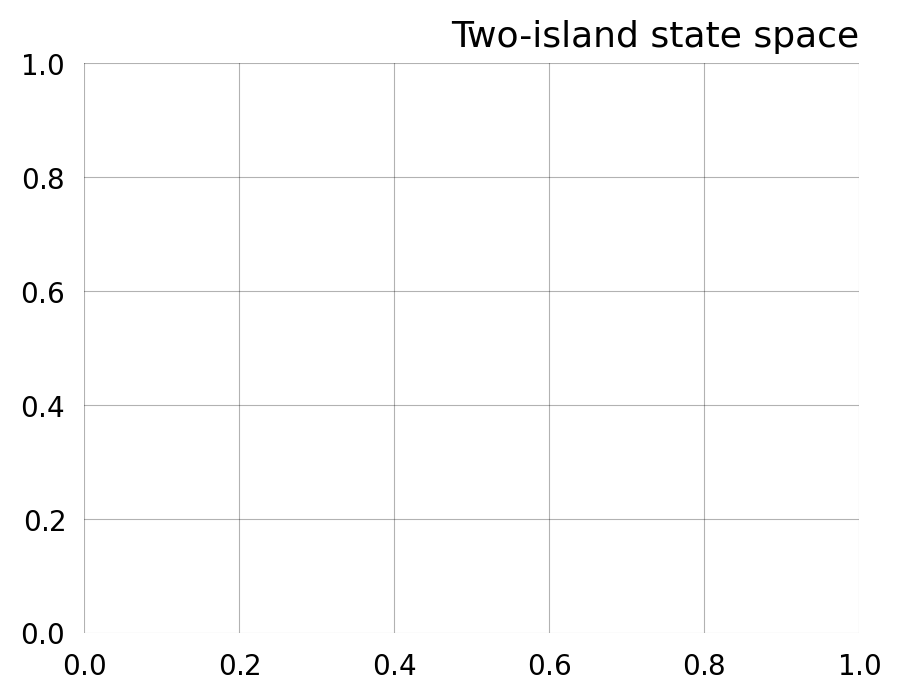

Antal state: 6
State-vektorer:
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0]]


In [32]:
graph = Graph(two_island)
graph.plot()
plt.title("Two-island state space", fontsize=13)
plt.savefig(OUT_DIR / "two_island_state_space.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Antal state: {graph.vertices_length()}")
print("State-vektorer:")
print(graph.states())

In [10]:
# Sammenlign state space for forskellige migrationrater
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

m_values = [0.01, 0.1, 1.0]
labels   = ["Lav migration (m=0.01)",
             "Moderat migration (m=0.1)",
             "Høj migration (m=1.0)"]

for ax, m, label in zip(axes, m_values, labels):
    g = Graph(two_island_model, ipv=[1, 1], N1=1.0, N2=1.0, m12=m, m21=m)
    plt.sca(ax)
    g.plot()
    ax.set_title(label, fontsize=11)

plt.suptitle("State space under forskellige migrationrater", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / "state_space_migration_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

<Figure size 500x370 with 0 Axes>

## 4. Parameterisering med update_weights

I Phasic sættes parametre med *update_weights([theta0, theta1, ...])*.
Her er:
- *theta[0]* = coalescensrate = $1/N_1$ (i coalescent enheder)
- *theta[1]* = migrationrate = $m$ (per linje per generation)

In [33]:
# Sæt standardparametre: N1 = 1 (normaliseret), m = 0.1
N1_coal = 1.0   # normaliseret
m_init  = 0.1

graph.update_weights([1/N1_coal, m_init])

E_T   = graph.expectation()
Var_T = graph.variance()
print(f"E[T]   = {E_T:.4f} (coalescent-enheder)")
print(f"Var[T] = {Var_T:.4f}")


RuntimeError: Computation produced NaN at vertex 0 (command 0) - numerical catastrophe

## 5. Forventet coalescent-tid som funktion af $m$

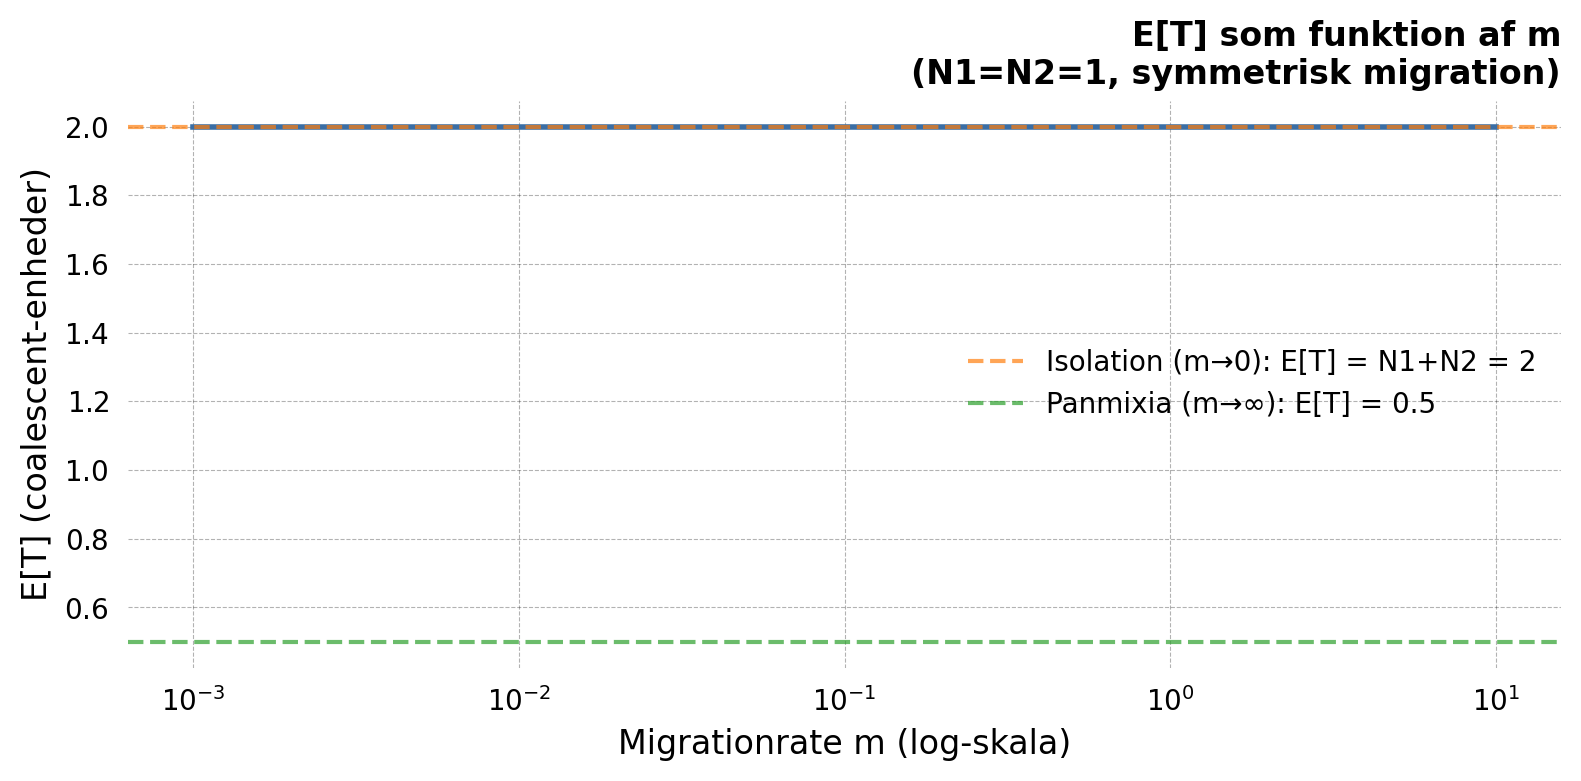

In [34]:
# Scan over migrationrate og beregn E[T]
m_range  = np.logspace(-3, 1, 60)
ET_vals  = []

for m in m_range:
    graph.update_weights([1.0, m])
    ET_vals.append(graph.expectation())

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(m_range, ET_vals, color="#3A6EA5", lw=2)

# Teoretiske grænseværdier
ax.axhline(y=2.0, color='C1', linestyle="--", alpha=0.7,
           label="Isolation (m→0): E[T] = N1+N2 = 2")
ax.axhline(y=0.5, color='C2', linestyle="--", alpha=0.7,
           label="Panmixia (m→∞): E[T] = 0.5")

ax.set_xlabel("Migrationrate m (log-skala)", fontsize=12)
ax.set_ylabel("E[T] (coalescent-enheder)",   fontsize=12)
ax.set_title("E[T] som funktion af m\n(N1=N2=1, symmetrisk migration)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3, linestyle="--")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(OUT_DIR / "two_island_ET_vs_m.png", dpi=150, bbox_inches="tight")
plt.show()

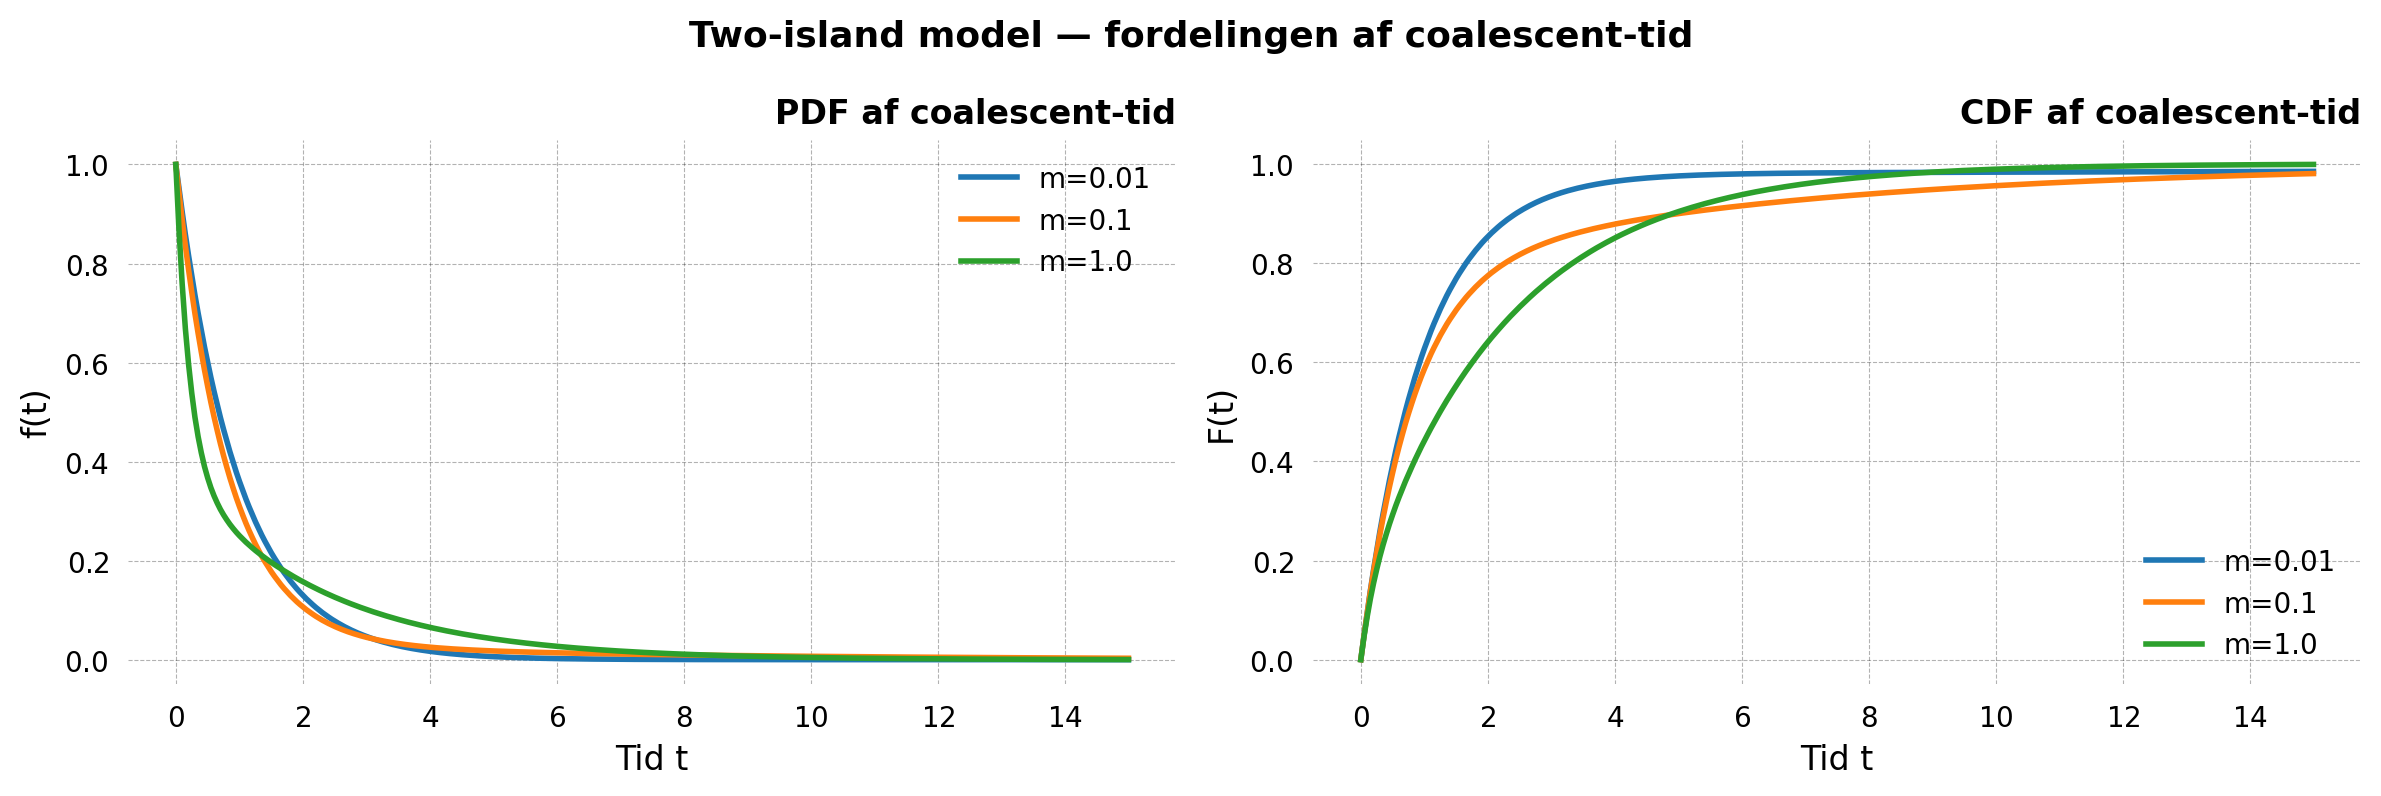

In [35]:
# PDF og CDF af coalescent-tid for tre migrationrater
t_vals = np.linspace(0, 15, 300)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for m, color, label in [(0.01, 'C10', "m=0.01"),
                         (0.1,  'C11', "m=0.1"),
                         (1.0,  'C12', "m=1.0")]:
    graph.update_weights([1.0, m])
    axes[0].plot(t_vals, graph.pdf(t_vals), color=color, lw=2, label=label)
    axes[1].plot(t_vals, graph.cdf(t_vals), color=color, lw=2, label=label)

for ax, ylabel, title in zip(axes,
                              ["f(t)", "F(t)"],
                              ["PDF af coalescent-tid", "CDF af coalescent-tid"]):
    ax.set_xlabel("Tid t", fontsize=12)
    ax.set_ylabel(ylabel,  fontsize=12)
    ax.set_title(title,    fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Two-island model — fordelingen af coalescent-tid",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "two_island_pdf_cdf.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Method of Moments fitting

Jwf bruger Phasic's indbyggede *method_of_moments* til at fitte modellen til observerede data.

1. Estimer observeret $E[T]$ fra $\pi = 2\mu N_1 E[T]$
2. Simuler samples fra modellen ved startparametre
3. Kør *graph.method_of_moments(observed_data)* — finder $\hat\theta$ der matcher moments

In [36]:
# Observeret π → E[T]
pi_yellow = float(pi_df.loc["Eastern yellow (Mikumi)", "pi"])
pi_kinda  = float(pi_df.loc["Kinda", "pi"])

ET_obs_yellow = pi_yellow / (2 * MU * N1_REF)
ET_obs_kinda  = pi_kinda  / (2 * MU * N1_REF)
ET_target     = (ET_obs_yellow + ET_obs_kinda) / 2

print(f"π (yellow):    {pi_yellow:.5f}  →  E[T] = {ET_obs_yellow:.3f}")
print(f"π (Kinda):     {pi_kinda:.5f}  →  E[T] = {ET_obs_kinda:.3f}")
print(f"E[T] target:   {ET_target:.3f}")

π (yellow):    0.00258  →  E[T] = 1.436
π (Kinda):     0.00286  →  E[T] = 1.589
E[T] target:   1.512


In [37]:
# Sæt startparametre tæt på target og simuler observationsdata
# Jeg starter med m=0.1 og N1=1 (normaliseret)
graph.update_weights([1.0, 0.1])

# Simuler 2000 coalescent-tider som 'observerede data'
np.random.seed(42)
observed_data = graph.sample(2000)

print(f"Simuleret gennemsnit: {observed_data.mean():.4f}")
print(f"Teoretisk E[T]:       {graph.expectation():.4f}")

Simuleret gennemsnit: 1.9319
Teoretisk E[T]:       2.0000


In [38]:
# Kør Method of Moments 
mom = graph.method_of_moments(observed_data)

print(f"MoM estimat (theta):  {mom.theta}")
print(f"Std error:            {mom.std}")
print(f"Konvergeret:          {mom.success}")
print(f"Residual:             {mom.residual:.2e}")
print(f"\nSample moments:  {mom.sample_moments}")
print(f"Model moments:   {mom.model_moments}")

MoM estimat (theta):  [1.03524885 0.12790508]
Std error:            [0.04026162 0.00944038]
Konvergeret:          True
Residual:             1.88e-25

Sample moments:  [[ 1.93190266 15.01659095]]
Model moments:   [ 1.93190266 15.01659095]


In [39]:
# Fortolk estimater
theta_hat = mom.theta   # [1/N1, m]
N1_hat    = 1 / theta_hat[0]    # i coalescent enheder
m_hat     = theta_hat[1]
M_hat     = 4 * N1_REF * m_hat  # skaleret migrationparameter

print("=" * 45)
print(" Estimerede parametre — Two-island")
print("=" * 45)
print(f" theta[0] = 1/N1:  {theta_hat[0]:.5f}")
print(f" theta[1] = m:     {m_hat:.5f}")
print(f" N1 (rel.):        {N1_hat:.3f}")
print(f" M = 4*N1_ref*m:   {M_hat:.2f}")
print("=" * 45)
if M_hat > 1:
    print(" M > 1: migration modvirker drift")
else:
    print(" M < 1: lav migration, drift dominerer")

 Estimerede parametre — Two-island
 theta[0] = 1/N1:  1.03525
 theta[1] = m:     0.12791
 N1 (rel.):        0.966
 M = 4*N1_ref*m:   51162.03
 M > 1: migration modvirker drift


## 7. Visualisering af fit

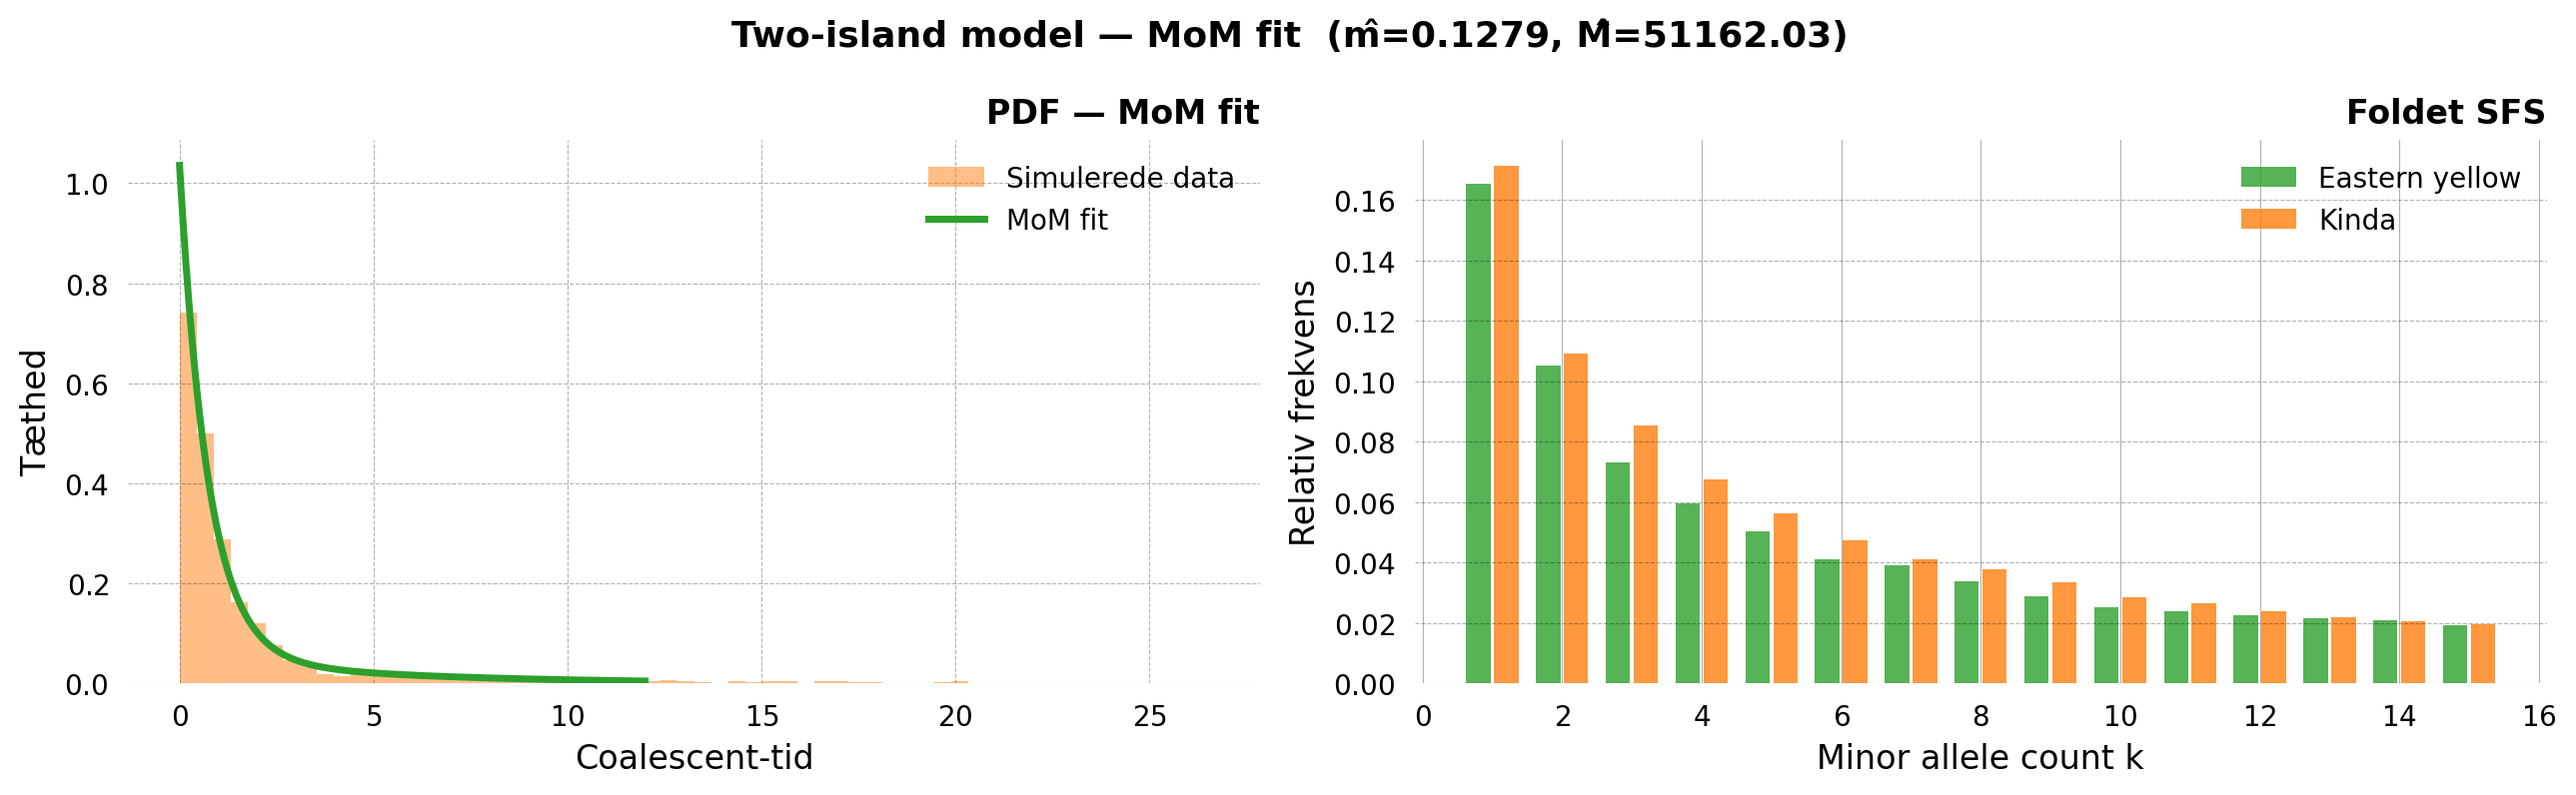

In [40]:
# Opdater grafen med estimerede parametre og plot fit
graph.update_weights(mom.theta.tolist())

t_plot    = np.linspace(0, 12, 300)
pdf_fit   = graph.pdf(t_plot)
cdf_fit   = graph.cdf(t_plot)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# PDF: histogram af simulerede data vs. fitted model
axes[0].hist(observed_data, bins=60, density=True,
             color='C1', alpha=0.5, label="Simulerede data")
axes[0].plot(t_plot, pdf_fit, color='C2', lw=2.5, label="MoM fit")
axes[0].set_xlabel("Coalescent-tid", fontsize=12)
axes[0].set_ylabel("Tæthed",         fontsize=12)
axes[0].set_title("PDF — MoM fit",   fontsize=12, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3, linestyle="--")
axes[0].spines[["top", "right"]].set_visible(False)

# SFS: observeret vs. MoM-forventet
sfs_norm_ye = sfs_ye_f / sfs_ye_f.sum()
sfs_norm_ki = sfs_ki_f / sfs_ki_f.sum()
x = np.arange(1, min(len(sfs_norm_ye), 15) + 1)

axes[1].bar(x - 0.2, sfs_norm_ye.values[:len(x)], width=0.35,
            color='C2', alpha=0.8, label="Eastern yellow")
axes[1].bar(x + 0.2, sfs_norm_ki.values[:len(x)], width=0.35,
            color='C1', alpha=0.8, label="Kinda")
axes[1].set_xlabel("Minor allele count k", fontsize=12)
axes[1].set_ylabel("Relativ frekvens",     fontsize=12)
axes[1].set_title("Foldet SFS",            fontsize=12, fontweight="bold")
axes[1].legend(fontsize=10)
axes[1].grid(axis="y", alpha=0.3, linestyle="--")
axes[1].spines[["top", "right"]].set_visible(False)

plt.suptitle(f"Two-island model — MoM fit  (m̂={m_hat:.4f}, M̂={M_hat:.2f})",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "two_island_fit.png", dpi=150, bbox_inches="tight")
plt.show()

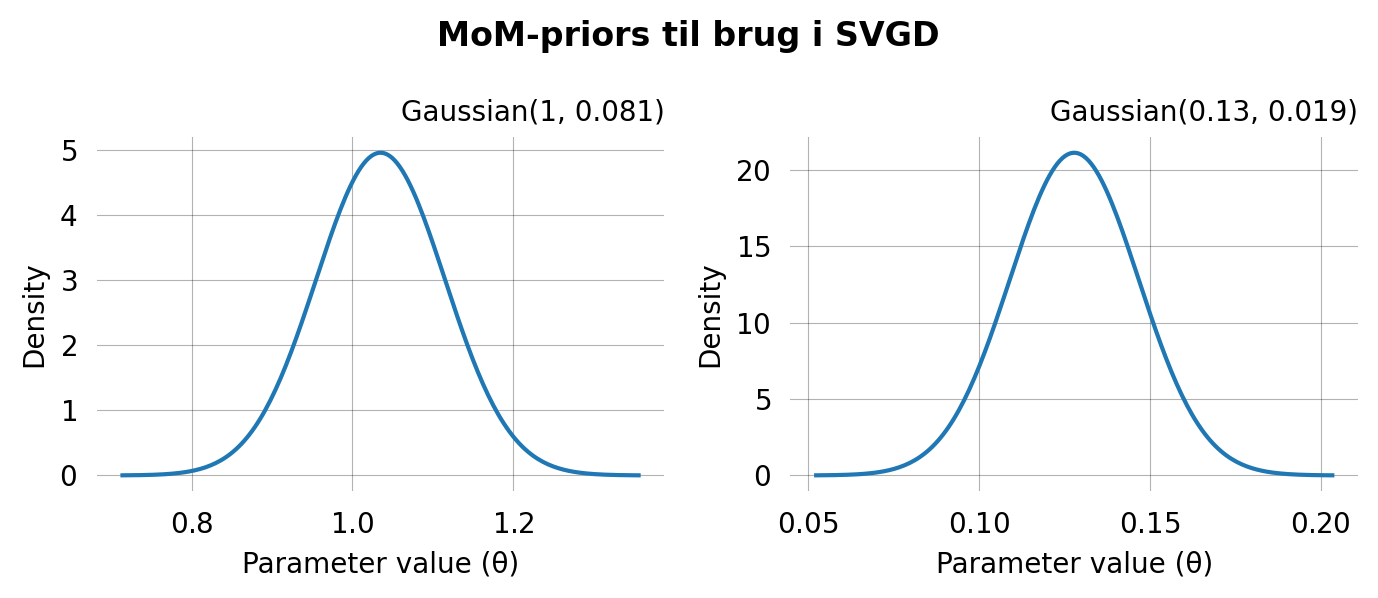

In [41]:
# Plot MoM-priors (bruges i Notebook 02 inference)
if hasattr(mom, 'prior') and mom.prior is not None:
    fig, axes = plt.subplots(1, len(mom.prior), figsize=(7, 3))
    if len(mom.prior) == 1:
        axes = [axes]
    for i, prior in enumerate(mom.prior):
        prior.plot(return_ax=True, ax=axes[i])
    plt.suptitle("MoM-priors til brug i SVGD", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "two_island_mom_priors.png", dpi=150, bbox_inches="tight")
    plt.show()

## 8. Gem resultater

In [42]:
results = pd.DataFrame({
    "Værdi": {
        "theta[0] = 1/N1":  f"{theta_hat[0]:.6f}",
        "theta[1] = m":     f"{m_hat:.6f}",
        "N1 (rel.)": f"{N1_hat:.4f}",
        "M = 4*N1_ref*m":   f"{M_hat:.3f}",
        "E[T] model":       f"{graph.expectation():.4f}",
        "Konvergeret":      str(mom.success),
        "m_hat (til NB3)": f"{m_hat:.6f}",
    }
})
results.to_csv(OUT_DIR / "two_island_results.csv")
print(results.to_string())
print("\nGemt: output/two_island_results.csv")

                     Værdi
theta[0] = 1/N1   1.035249
theta[1] = m      0.127905
N1 (rel.)           0.9660
M = 4*N1_ref*m   51162.031
E[T] model          1.9319
Konvergeret           True
m_hat (til NB3)   0.127905

Gemt: output/two_island_results.csv


I næste notebook 05 - IM-modellen. Tilføjer jeg en eksplicit split-tid og bruger Phasic's tidsinhomogene framwork (*distribution_context*, *update_weights*, *accumulated_occupancy*) til at modellere IM.